## Handling Time-Series Data

Time-series data is sequential data points over time. Time-series data is a sequence of observations recorded at regular time intervals, where order of time matters. It requires special handling for trends, seasonality, and autocorrelation.

### Characterstics
- Chronological Order
 Observations are ordered by time, and changing the order changes the meaning of data.

- Trend
 Long-term increase or decrease in the data (e.g., rising stock prices).

- Seasonality
Repeating patterns at fixed intervals (daily, monthly, yearly).

- Cyclic Behavior
Long-term fluctuations without a fixed period (e.g., economic cycles).

- Autocorrelation
Current values depend on past values.

- Stationarity (or Non-stationarity)
Mean, variance, and covariance may change over time. 

### Techniques
1. **Parsing Dates**: Convert strings to datetime.
2. **Resampling**: Aggregate data over time periods. Change the frequency of data (e.g., daily → monthly) using aggregation like mean, sum, or max.
3. **Shifting and Rolling**: Create lag features or moving averages.
4. **Decomposition**: Separate trend, seasonality, residuals.
5. **Stationarity Tests**: Check and make data stationary.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [ ]:
# Sample time-series data
dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
data_ts = {
    'Date': dates,
    'Value': np.random.randn(100).cumsum() + np.sin(np.linspace(0, 10, 100)) * 10 
    # Adding some noise + trend +seasonality
}
df_ts = pd.DataFrame(data_ts)
df_ts.set_index('Date', inplace=True)
print("Original Time-Series DataFrame:")
print(df_ts.head())

Original Time-Series DataFrame:
               Value
Date                
2020-01-01  1.023567
2020-01-02  2.908997
2020-01-03  3.325984
2020-01-04  5.016620
2020-01-05  6.180345


### 1. Resampling 

Resampling means changing the time frequency of a time-series dataset.
You either reduce frequency (downsampling) or increase frequency (upsampling) while applying an aggregation or filling rule.

#### Downsampling (Reducing Frequency)

Downsampling converts data from a higher frequency to a lower frequency.
Example: Daily → Monthly ,Daily → Weekly
Common aggregation function :
- mean() – average value
- sum() – total (used for sales, volume)

#### Upsampling (Increasing Frequency)

Upsampling converts data from a lower frequency to a higher frequency.
Example: Monthly → Daily ,Weekly → Hourly
Upsampling creates new timestamps where no original observations exist, resulting in missing values

In [3]:
# Resample to weekly mean
df_weekly = df_ts.resample('W').mean()
print("\nWeekly Resampled Data:")
print(df_weekly.head())


Weekly Resampled Data:
               Value
Date                
2020-01-05  3.691103
2020-01-12  8.485487
2020-01-19  8.032896
2020-01-26  2.704435
2020-02-02 -5.170375


In [5]:
# Upsampling
df_daily_upsampled = df_weekly.resample('D').asfreq()
print("\nDaily Upsampled Data (With NaN):")
print(df_daily_upsampled.head(10))
# Fill missing values using forward fill
df_daily_filled = df_daily_upsampled.fillna(method='ffill')
print("\nDaily Upsampled Data (After Forward Fill):")
print(df_daily_filled.head(10))


Daily Upsampled Data (With NaN):
               Value
Date                
2020-01-05  3.691103
2020-01-06       NaN
2020-01-07       NaN
2020-01-08       NaN
2020-01-09       NaN
2020-01-10       NaN
2020-01-11       NaN
2020-01-12  8.485487
2020-01-13       NaN
2020-01-14       NaN

Daily Upsampled Data (After Forward Fill):
               Value
Date                
2020-01-05  3.691103
2020-01-06  3.691103
2020-01-07  3.691103
2020-01-08  3.691103
2020-01-09  3.691103
2020-01-10  3.691103
2020-01-11  3.691103
2020-01-12  8.485487
2020-01-13  8.485487
2020-01-14  8.485487


/tmp/ipykernel_9535/1350441944.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily_filled = df_daily_upsampled.fillna(method='ffill')


### 2. Shifting and Rolling Windows

Shifting and Rolling Windows are core techniques in time-series analysis used to create lagged features, smooth noise, and capture temporal patterns—especially important for forecasting and ML models.

Shifting moves data forward or backward in time without changing values, only their position. It’s mainly used to create lag features (past values).


A rolling window applies a function over a fixed-size sliding window of past observations. It's mainly used to smooth the data.


In [6]:
# Shift (lag) by 1 period
df_ts['Lag_1'] = df_ts['Value'].shift(1)

# Rolling mean with window 7
df_ts['Rolling_7'] = df_ts['Value'].rolling(window=7).mean()

print("\nAfter Shifting and Rolling:")
print(df_ts.head(10))


After Shifting and Rolling:
               Value     Lag_1  Rolling_7
Date                                     
2020-01-01  1.023567       NaN        NaN
2020-01-02  2.908997  1.023567        NaN
2020-01-03  3.325984  2.908997        NaN
2020-01-04  5.016620  3.325984        NaN
2020-01-05  6.180345  5.016620        NaN
2020-01-06  8.152423  6.180345        NaN
2020-01-07  6.825275  8.152423   4.776173
2020-01-08  8.566988  6.825275   5.853805
2020-01-09  9.346987  8.566988   6.773518
2020-01-10  8.140508  9.346987   7.461307


### 3. Decomposition 

Decomposition is the process of breaking a time-series into its individual components so that underlying patterns become easier to understand, analyze, and model.

A time-series is typically decomposed into:

- Trend : The long-term upward or downward movement in the data over time. 

- Seasonality : Regular and repeating patterns that occur at fixed time intervals, such as daily, monthly, or yearly.

- Residual (Noise) : Random or irregular fluctuations that cannot be explained by trend or seasonality.


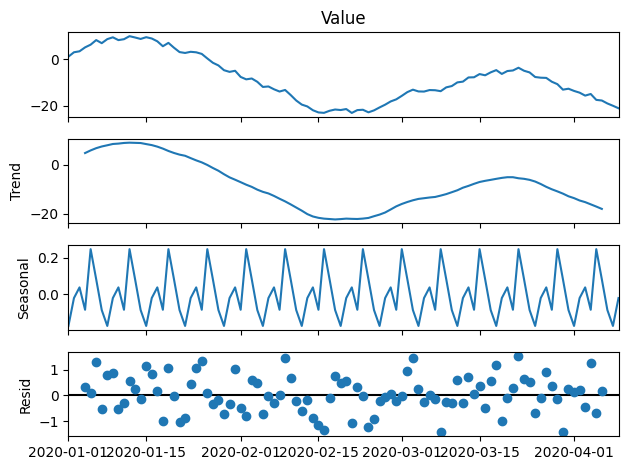

In [7]:
# Decompose the time series
decomp = seasonal_decompose(df_ts['Value'], model='additive', period=7)
fig = decomp.plot()
plt.show() 

### 4. Stationarity Test

A stationarity test is used to check whether a time-series data is stationary or non-stationary.

A time-series is said to be stationary if its:

- Mean remains constant over time

- Variance remains constant over time

- Autocorrelation does not depend on time

We need to check stationary for making prediction easier, because it assumes some statistical properties throughout the time.

Forecasting models requires a stationary data.


#### Testing For Stationary

ADF tests for non-stationarity (unit root) while KPSS tests for stationarity; they are complementary tests used together to confirm the nature of a time-series.


##### ADF Test (Augmented Dickey-Fuller):
- Purpose: Checks if a time-series is non-stationary
- Null Hypothesis (H₀): The series is non-stationary
- Alternative Hypothesis (H₁): The series is stationary
- Decision Rule:
  - If p-value < 0.05 → Reject H₀ → Data is stationary
  - If p-value ≥ 0.05 → Fail to reject H₀ → Data is non-stationary

##### KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin) :
- Purpose: Checks if a time-series is stationary
- Null Hypothesis (H₀): The series is stationary
- Alternative Hypothesis (H₁): The series is non-stationary
- Decision Rule:
  - If p-value < 0.05 → Reject H₀ → Data is non-stationary
  - If p-value ≥ 0.05 → Fail to reject H₀ → Data is stationary


In [12]:
import yfinance as yf
 
stock_data = yf.download('AAPL', start='2024-01-01')
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.903229,186.677036,182.169601,185.399096,82488700
2024-01-03,182.526215,184.140970,181.713879,182.496496,58414500
2024-01-04,180.208130,181.377083,179.187767,180.445875,71983600
2024-01-05,179.484940,181.050159,178.484394,180.287374,62379700
2024-01-08,183.823975,183.863609,179.801961,180.386437,59144500


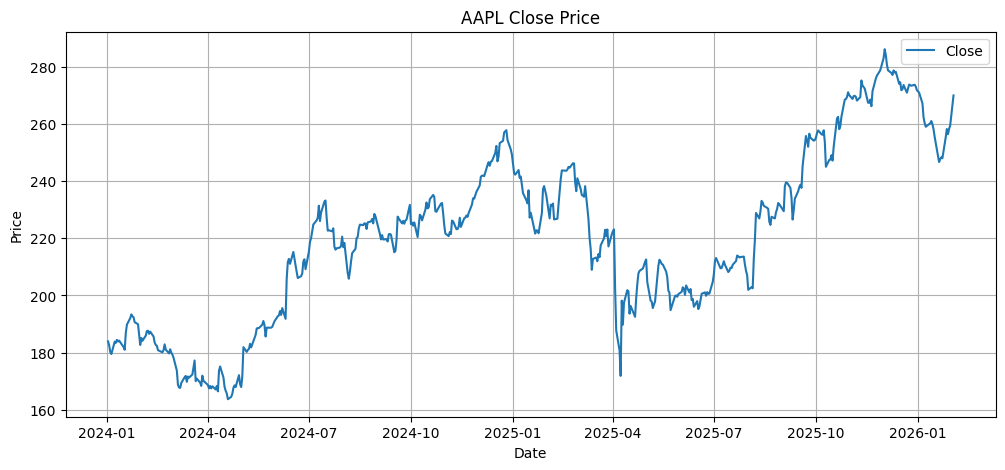

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(stock_data.index,stock_data['Close'], label='Close')
plt.title('AAPL Close Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
decomposition_additictive =seasonal_decompose(stock_data['Close'],model='addictive', period=30)

In [16]:
trend_addictive = decomposition_additictive.trend
seasonal_addictive = decomposition_additictive.seasonal
residual_addictive = decomposition_additictive.resid

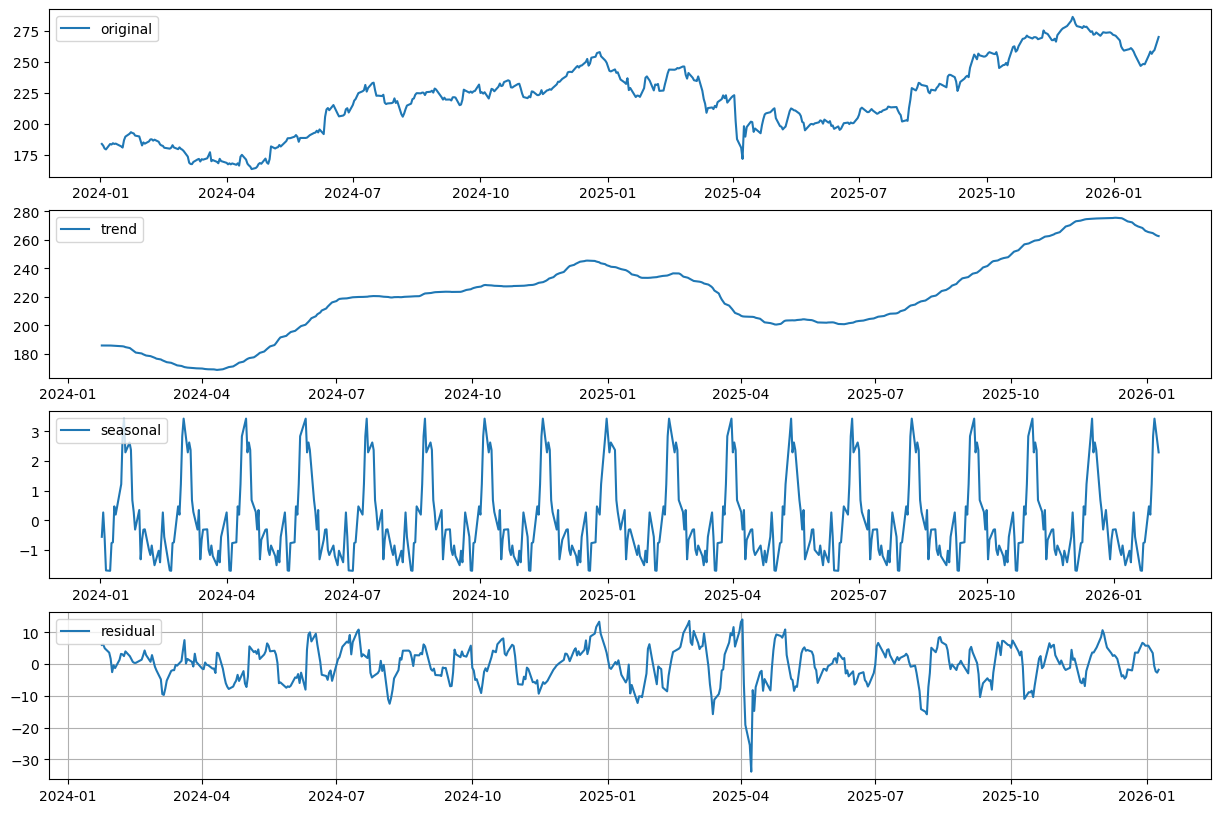

In [19]:
plt.figure(figsize=(15, 10))
plt.subplot(411)
plt.plot(stock_data['Close'], label='original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_addictive, label='trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_addictive, label='seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_addictive, label='residual')
plt.legend(loc='upper left')

# plt.legend()
plt.grid(True)
plt.show()

#### STL Decomposition :
STL stands for Seasonal-Trend decomposition using Loess.
It is an advanced method to decompose a time-series. Unlike classical decomposition, STL is more flexible and can handle non-linear trends and changing seasonality.

In [20]:
from statsmodels.tsa.seasonal import STL
stl =STL(stock_data['Close'], period=30)
result = stl.fit()

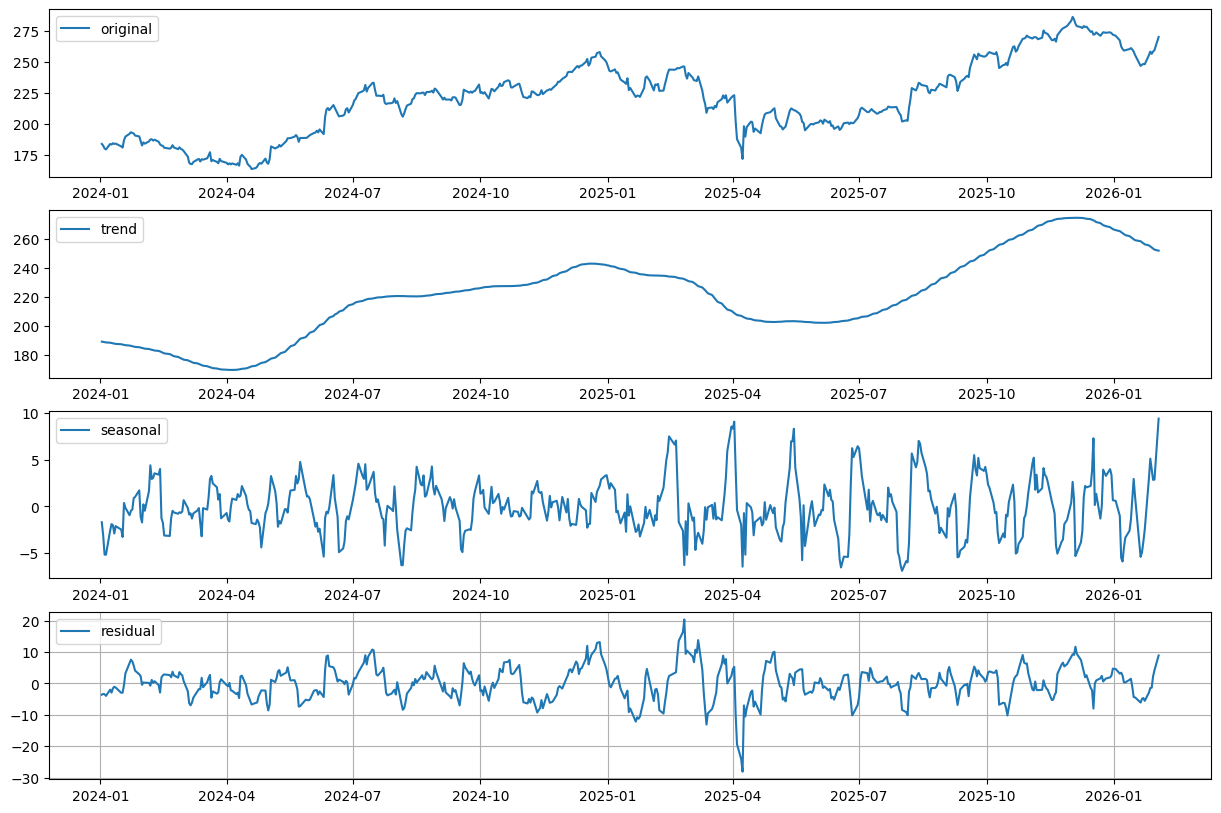

In [21]:
plt.figure(figsize=(15, 10))
plt.subplot(411)
plt.plot(result.observed, label='original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend, label='trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal, label='seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid, label='residual')
plt.legend(loc='upper left')

# plt.legend()
plt.grid(True)
plt.show()

<h1>Stationarity Test</h1>

In [22]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(stock_data['Close'])
print(f'Adf statistic: {round(adf_test[0],3)}')
print(f'p-value: {round(adf_test[1],3)}')
print('Critical values:')
for key, value in adf_test[4].items():
    print(f' {key}: {round(value,3)}')

Adf statistic: -1.357
p-value: 0.603
Critical values:
 1%: -3.443
 5%: -2.867
 10%: -2.57


ADF statistic = -1.357

Critical values (5% level) = -2.867

−1.357 > −2.867  If ADF statistic greater than critical value we accept H₀ i.e, Series is non-stationary

Also in p-value 0.603 > 0.05 , If p ≥ 0.05 we Fail to reject H₀ i.e,  Series is non-stationary

In [23]:
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(stock_data['Close'],regression='ct')
print(f'kpss statistic: {round(kpss_test[0],2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical values:')
for key, value in kpss_test[3].items():
    print(f' {key}: {value}')

kpss statistic: 0.28
p-value: 0.01
Critical values:
 10%: 0.119
 5%: 0.146
 2.5%: 0.176
 1%: 0.216


/tmp/ipykernel_9535/433235444.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(stock_data['Close'],regression='ct')


 - The KPSS statistic (0.28) is greater than the 5% critical value (0.146) and the p-value (0.01) < 0.05, so we reject the null hypothesis (H₀). Therefore, the series is non-stationary.

#### Making the time series data stationarity

Many forecasting models like ARIMA require the input data to be stationary, i.e., the mean, variance, and autocorrelation do not change over time.

If your stationarity tests (ADF, KPSS) show that the series is non-stationary, you need to transform the data before modeling.

##### Common Technique to Make Time-Series Stationary 

- Differencing :
    Subtract the previous observation from the current one.
    Can remove trend and seasonality (seasonal differencing).
        Yt′​= Yt ​− Yt−1​

In [25]:
def adf_test(series):
    result = adfuller(series)
    print(f'Adf statistic: {round(result[0],3)}')
    print(f'p-value: {result[1]}')
    print('Critical values:')
    for key, value in result[4].items():
        print(f' {key}: {round(value,3)}')
        
        
def kpss_test(series):
    result = kpss(series,regression='ct')
    print(f'kpss statistic: {round(result[0],2)}')
    print(f'p-value: {result[1]}')
    print('Critical values:')
    for key, value in result[3].items():
        print(f' {key}: {value}')
        
        

In [28]:
prices =stock_data['Close']
adf_test(prices)

Adf statistic: -1.357
p-value: 0.6025925578729495
Critical values:
 1%: -3.443
 5%: -2.867
 10%: -2.57


In [31]:
prices_diff=prices.diff()
adf_test(prices_diff.dropna())

Adf statistic: -13.135
p-value: 1.4654266488591466e-24
Critical values:
 1%: -3.443
 5%: -2.867
 10%: -2.57


The ADF statistic (-13.135) is much smaller than the 1%, 5%, and 10% critical values, and the p-value (~0) < 0.05, so we reject H₀. Therefore, the series is stationary, suitable for modeling with ARIMA or other forecasting methods.